Mon Jun  1 11:16:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

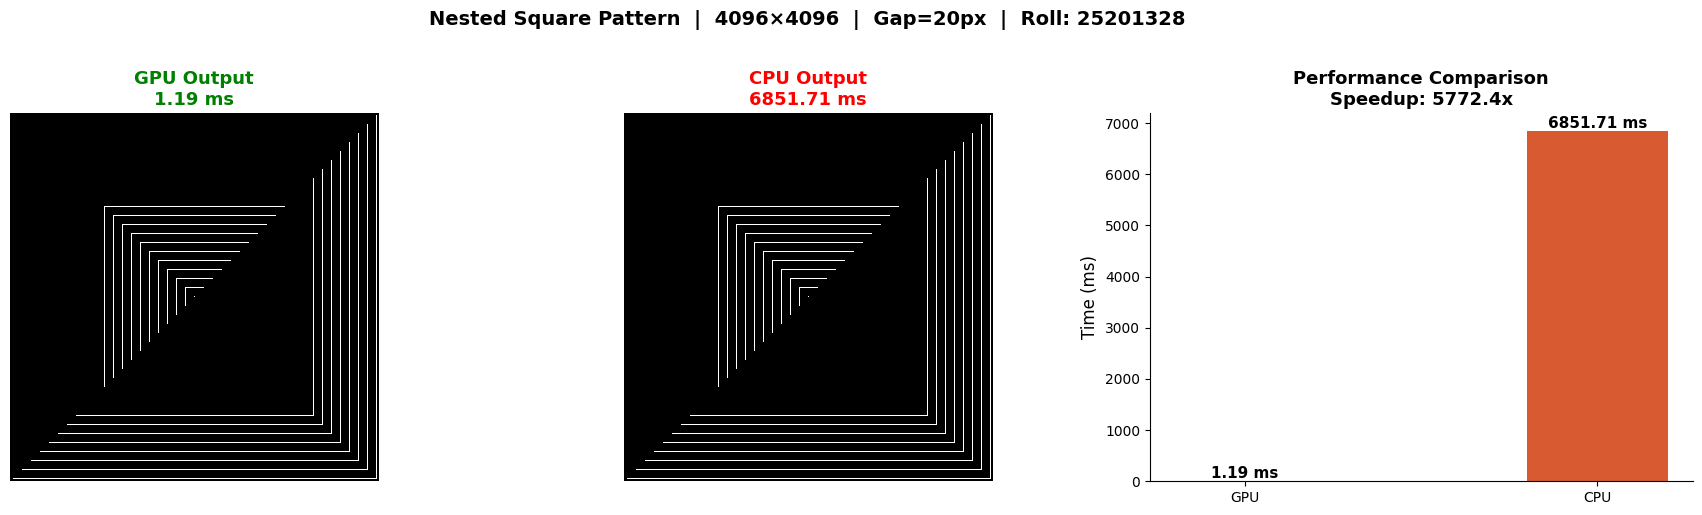


Done! All outputs saved.


In [1]:
# ============================================================
# Hard (CO4) | DS11 | Roll: 25201328
# Nested Square Pattern — CUDA GPU vs Sequential CPU
# Run on: Google Colab (Runtime > Change runtime type > GPU)
# ============================================================

# ── Step 1: Install dependencies ────────────────────────────
!pip install numba matplotlib Pillow --quiet

# ── Step 2: Verify GPU is available ─────────────────────────
!nvidia-smi

# ── Step 3: All imports ──────────────────────────────────────
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from PIL import Image
from numba import cuda

# ── Step 4: Configuration ────────────────────────────────────
WIDTH   = 4096   # image width  in pixels
HEIGHT  = 4096   # image height in pixels
GAP     = 20     # spacing between concentric squares (pixels)
BLOCK   = 16     # 16x16 = 256 threads per block

# ── Step 5: CUDA Kernel ──────────────────────────────────────
# Each thread handles exactly ONE pixel (x, y).
# Chebyshev distance from centre: d = max(|cx|, |cy|)
# If d % GAP == 0  →  pixel is ON a square boundary → WHITE (255)
# Otherwise        →  BLACK (0)

@cuda.jit
def nested_squares_kernel(img, width, height, gap):
    x, y = cuda.grid(2)                       # 2D thread index
    if x >= width or y >= height:
        return                                 # boundary guard
    cx   = x - width  // 2                    # centre-relative x
    cy   = y - height // 2                    # centre-relative y
    dist = max(abs(cx), abs(cy))              # Chebyshev distance
    if dist % gap == 0:
        img[y, x] = 255                        # square edge → white
    else:
        img[y, x] = 0                          # interior/exterior → black

# ── Step 6: CPU Reference (sequential, single-threaded) ──────
def nested_squares_cpu(width, height, gap):
    img = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            cx   = x - width  // 2
            cy   = y - height // 2
            dist = max(abs(cx), abs(cy))
            if dist % gap == 0:
                img[y, x] = 255
    return img

# ── Step 7: GPU Execution ─────────────────────────────────────
print("=" * 55)
print("  Nested Square Pattern  |  Roll: 25201328")
print(f"  Grid: {WIDTH} x {HEIGHT}  |  Gap: {GAP} px  |  Squares: ~{(WIDTH//2)//GAP}")
print("=" * 55)

# Allocate output array on host, then transfer to device
h_img = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)
d_img = cuda.to_device(h_img)

# Configure 2D grid of 16x16 blocks
threads_per_block = (BLOCK, BLOCK)
blocks_per_grid_x = math.ceil(WIDTH  / BLOCK)
blocks_per_grid_y = math.ceil(HEIGHT / BLOCK)
blocks_per_grid   = (blocks_per_grid_x, blocks_per_grid_y)

# Warm-up launch (avoids JIT compilation time in the measured run)
nested_squares_kernel[blocks_per_grid, threads_per_block](d_img, WIDTH, HEIGHT, GAP)
cuda.synchronize()

# Timed GPU launch
gpu_start = time.perf_counter()
nested_squares_kernel[blocks_per_grid, threads_per_block](d_img, WIDTH, HEIGHT, GAP)
cuda.synchronize()                             # wait for GPU to finish
gpu_end   = time.perf_counter()
gpu_ms    = (gpu_end - gpu_start) * 1000.0

# Copy result back to host
gpu_img = d_img.copy_to_host()

print(f"\n[GPU] Kernel time      : {gpu_ms:.4f} ms")
print(f"[GPU] Blocks launched  : {blocks_per_grid_x} x {blocks_per_grid_y} = {blocks_per_grid_x*blocks_per_grid_y:,}")
print(f"[GPU] Threads per block: {BLOCK} x {BLOCK} = {BLOCK*BLOCK}")
print(f"[GPU] Total threads    : {blocks_per_grid_x*blocks_per_grid_y*BLOCK*BLOCK:,}")

# ── Step 8: CPU Execution (sequential) ───────────────────────
print("\n[CPU] Running sequential version...")
cpu_start = time.perf_counter()
cpu_img   = nested_squares_cpu(WIDTH, HEIGHT, GAP)
cpu_end   = time.perf_counter()
cpu_ms    = (cpu_end - cpu_start) * 1000.0

print(f"[CPU] Sequential time  : {cpu_ms:.4f} ms")

# ── Step 9: Verify both outputs match ────────────────────────
match = np.array_equal(gpu_img, cpu_img)
print(f"\n[VERIFY] GPU == CPU    : {'PASS ✓' if match else 'FAIL ✗'}")

# ── Step 10: Performance comparison ──────────────────────────
speedup = cpu_ms / gpu_ms
print(f"[SPEEDUP]              : {speedup:.2f}x")
print(f"  CPU: {cpu_ms:.2f} ms  →  GPU: {gpu_ms:.2f} ms")
print("=" * 55)

# ── Step 11: Save output images ───────────────────────────────
Image.fromarray(gpu_img).save("gpu_nested_squares.png")
Image.fromarray(cpu_img).save("cpu_nested_squares.png")
print("\nImages saved: gpu_nested_squares.png, cpu_nested_squares.png")

# ── Step 12: Visualise results ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GPU output
axes[0].imshow(gpu_img, cmap='gray', interpolation='nearest')
axes[0].set_title(f'GPU Output\n{gpu_ms:.2f} ms', fontsize=13, fontweight='bold', color='green')
axes[0].axis('off')

# CPU output
axes[1].imshow(cpu_img, cmap='gray', interpolation='nearest')
axes[1].set_title(f'CPU Output\n{cpu_ms:.2f} ms', fontsize=13, fontweight='bold', color='red')
axes[1].axis('off')

# Performance bar chart
labels  = ['GPU', 'CPU']
times   = [gpu_ms, cpu_ms]
colors  = ['#1D9E75', '#D85A30']
bars    = axes[2].bar(labels, times, color=colors, width=0.4, edgecolor='none')
axes[2].set_ylabel('Time (ms)', fontsize=12)
axes[2].set_title(f'Performance Comparison\nSpeedup: {speedup:.1f}x', fontsize=13, fontweight='bold')
for bar, val in zip(bars, times):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.2f} ms',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(f'Nested Square Pattern  |  {WIDTH}×{HEIGHT}  |  Gap={GAP}px  |  Roll: 25201328',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nDone! All outputs saved.")